<a href="https://colab.research.google.com/github/chetancharpe/machine-learning/blob/main/ML_by_%22campusX%22_%3EYT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install -q kaggle

In [ ]:
# import os
# from google.colab import userdata

# os.environ["KGAT_47e503057ee6bc386e8aa80dcda9712c"]=userdata.get("kaggle_api_token")

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv('/content/placement-dataset.csv')

In [ ]:
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [ ]:
df=df.dropna()

In [ ]:
df.shape

(88, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       88 non-null     object 
 1   cgpa       88 non-null     float64
 2   iq         88 non-null     float64
 3   placement  88 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 3.4+ KB


In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
3,7.4,132.0,1
4,5.8,142.0,0
5,7.1,48.0,1


In [ ]:
import matplotlib.pyplot as plt

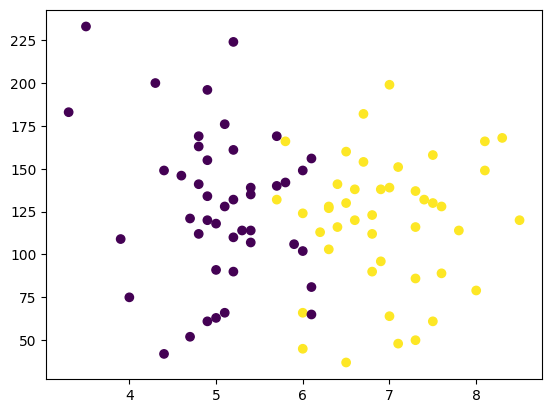

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
3,1
4,0
5,1
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,cgpa,iq
84,5.7,169.0
30,7.6,128.0
53,8.3,168.0
56,6.1,65.0
25,5.0,91.0
...,...,...
99,6.2,113.0
33,6.0,149.0
94,4.7,52.0
12,5.4,139.0


In [ ]:
y_train

,placement
84,0
30,1
53,1
56,0
25,0
...,...
99,1
33,0
94,0
12,0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-2.22786117e-01,  1.09482733e+00],
       [ 1.44090523e+00,  1.20879040e-01],
       [ 2.05384415e+00,  1.07107249e+00],
       [ 1.27464694e-01, -1.37567564e+00],
       [-8.35725034e-01, -7.58049901e-01],
       [-1.09841314e+00, -4.54048136e-02],
       [ 3.90152801e-01, -1.64178995e-01],
       [ 3.02590099e-01, -4.72991866e-01],
       [ 1.35334253e+00, -1.47069499e+00],
       [-7.48162332e-01,  1.20879040e-01],
       [ 2.22896955e+00, -6.91596498e-02],
       [-1.79891476e+00, -3.30462849e-01],
       [ 1.27464694e-01, -9.95598263e-01],
       [ 1.17821712e+00, -1.64178995e-01],
       [ 5.65278206e-01,  3.58427403e-01],
       [ 1.87871874e+00,  1.02356282e+00],
       [ 3.99019910e-02, -1.85077237e+00],
       [-9.23287737e-01, -6.91596498e-02],
       [ 5.65278206e-01, -6.91596498e-02],
       [ 8.27966314e-01,  3.58427403e-01],
       [-2.14916557e+00,  2.61513685e+00],
       [-9.23287737e-01,  7.62259619e-01],
       [-2.32429098e+00,  1.42739503e+00],
       [ 3.

In [ ]:
x_test=scaler.transform(x_test)

In [ ]:
x_test

array([[ 1.35334253,  0.16838871],
       [-0.57303693, -0.21168867],
       [-0.13522341,  1.02356282],
       [-1.01085044,  0.95229831],
       [-1.01085044,  0.42969191],
       [ 0.3025901 ,  0.0971242 ],
       [ 1.61603064, -0.21168867],
       [ 1.87871874,  0.6197306 ],
       [ 1.17821712, -1.73199819]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
#Model training
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
y_test

,placement
83,1
46,0
85,1
34,0
51,0
70,1
55,1
37,1
77,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8888888888888888

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

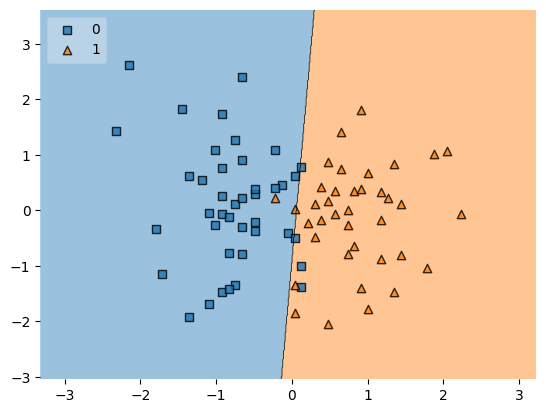

In [ ]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')